In [1]:
import cv2
import numpy as np
from pathlib import Path

In [2]:
# done drawing polygon
#VIDEO_PATH = "D:/store-intelligence-system/data/raw/Store_1/CAM_3-entry.mp4"  
#VIDEO_PATH = "D:/store-intelligence-system/data/raw/Store_1/CAM_2-zone.mp4"
#VIDEO_PATH = "D:/store-intelligence-system/data/raw/Store_1/CAM_1-zone.mp4"
#VIDEO_PATH = "D:/store-intelligence-system/data/raw/Store_1/CAM_5-billing.mp4"
# current
VIDEO_PATH = "D:/store-intelligence-system/data/raw/Store_2/entry_1.mp4"
# remains
#VIDEO_PATH = "D:/store-intelligence-system/data/raw/Store_2/entry_2.mp4"
#VIDEO_PATH = "D:/store-intelligence-system/data/raw/Store_2/billing_area.mp4"
#VIDEO_PATH = "D:/store-intelligence-system/data/raw/Store_2/zone.mp4"

In [3]:
# Initialize video capture
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise ValueError(f"Unable to open video: {VIDEO_PATH}")

print("Video opened successfully!")

Video opened successfully!


In [4]:
# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps

print(f"FPS: {fps}")
print(f"Frame Count: {frame_count}")
print(f"Resolution: {width}x{height}")
print(f"Duration: {duration:.2f} seconds")

FPS: 25.0
Frame Count: 2636
Resolution: 960x1080
Duration: 105.44 seconds


In [5]:
# read first frame
ret, frame = cap.read()

print("Frame shape:", frame.shape)
print("Frame dtype:", frame.dtype)

Frame shape: (1080, 960, 3)
Frame dtype: uint8


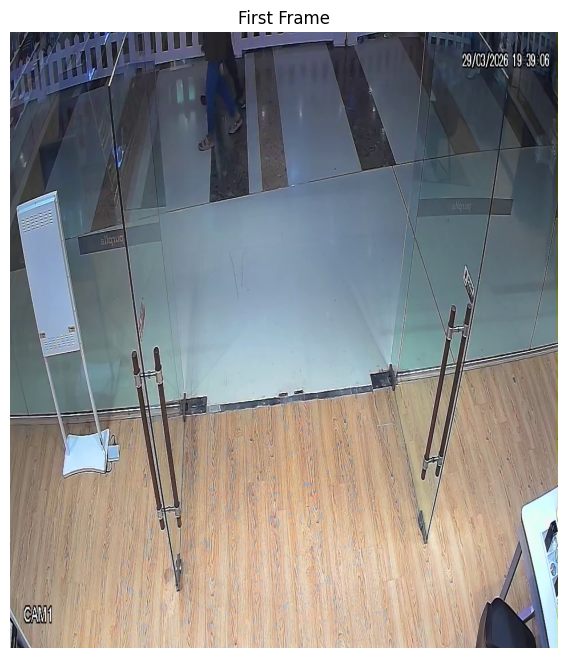

In [6]:
# Display the first frame using matplotlib
import matplotlib.pyplot as plt

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.title("First Frame")
plt.axis("off")
plt.show()

In [9]:
# Frame iteration test
frame_id = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    timestamp = frame_id / fps

    print(f"Frame: {frame_id}, Timestamp: {timestamp:.2f}s")

    frame_id += 1

    if frame_id == 10:
        break

Frame: 0, Timestamp: 0.00s
Frame: 1, Timestamp: 0.03s
Frame: 2, Timestamp: 0.07s
Frame: 3, Timestamp: 0.10s
Frame: 4, Timestamp: 0.13s
Frame: 5, Timestamp: 0.17s
Frame: 6, Timestamp: 0.20s
Frame: 7, Timestamp: 0.23s
Frame: 8, Timestamp: 0.27s
Frame: 9, Timestamp: 0.30s


In [10]:
# Test resizing
TARGET_WIDTH = 1280
TARGET_HEIGHT = 720

resized_frame = cv2.resize(frame, (TARGET_WIDTH, TARGET_HEIGHT))

print("Original Shape:", frame.shape)
print("Resized Shape:", resized_frame.shape)

Original Shape: (1080, 1920, 3)
Resized Shape: (720, 1280, 3)


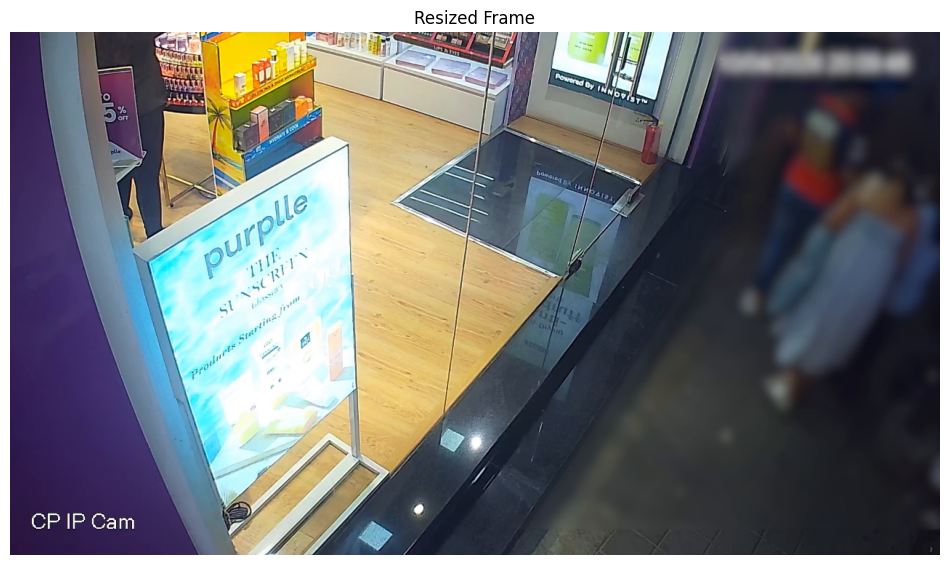

In [11]:
# Display the resized frame
resized_rgb = cv2.cvtColor(resized_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(resized_rgb)
plt.title("Resized Frame")
plt.axis("off")
plt.show()

In [12]:
# Test frame skipping
FRAME_SKIP = 10

cap = cv2.VideoCapture(VIDEO_PATH)

frame_id = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    if frame_id % FRAME_SKIP == 0:

        timestamp = frame_id / fps

        print(f"Processing Frame: {frame_id} | Timestamp: {timestamp:.2f}s")

    frame_id += 1

Processing Frame: 0 | Timestamp: 0.00s
Processing Frame: 10 | Timestamp: 0.33s
Processing Frame: 20 | Timestamp: 0.67s
Processing Frame: 30 | Timestamp: 1.00s
Processing Frame: 40 | Timestamp: 1.33s
Processing Frame: 50 | Timestamp: 1.67s
Processing Frame: 60 | Timestamp: 2.00s
Processing Frame: 70 | Timestamp: 2.34s
Processing Frame: 80 | Timestamp: 2.67s
Processing Frame: 90 | Timestamp: 3.00s
Processing Frame: 100 | Timestamp: 3.34s
Processing Frame: 110 | Timestamp: 3.67s
Processing Frame: 120 | Timestamp: 4.00s
Processing Frame: 130 | Timestamp: 4.34s
Processing Frame: 140 | Timestamp: 4.67s
Processing Frame: 150 | Timestamp: 5.00s
Processing Frame: 160 | Timestamp: 5.34s
Processing Frame: 170 | Timestamp: 5.67s
Processing Frame: 180 | Timestamp: 6.01s
Processing Frame: 190 | Timestamp: 6.34s
Processing Frame: 200 | Timestamp: 6.67s
Processing Frame: 210 | Timestamp: 7.01s
Processing Frame: 220 | Timestamp: 7.34s
Processing Frame: 230 | Timestamp: 7.67s
Processing Frame: 240 | Tim

In [13]:
# Frame Generator
def frame_generator(video_path, frame_skip=1):

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)

    frame_id = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_id % frame_skip == 0:

            timestamp = frame_id / fps

            yield {
                "frame": frame,
                "frame_id": frame_id,
                "timestamp": timestamp
            }

        frame_id += 1

    cap.release()

In [14]:
# Test the frame generator
generator = frame_generator(VIDEO_PATH, frame_skip=5)

for item in generator:

    print(
        item["frame_id"],
        item["timestamp"],
        item["frame"].shape
    )

    break

0 0.0 (1080, 1920, 3)
